c0_fit = -12.675110
L2 loss = 4.295172e-02


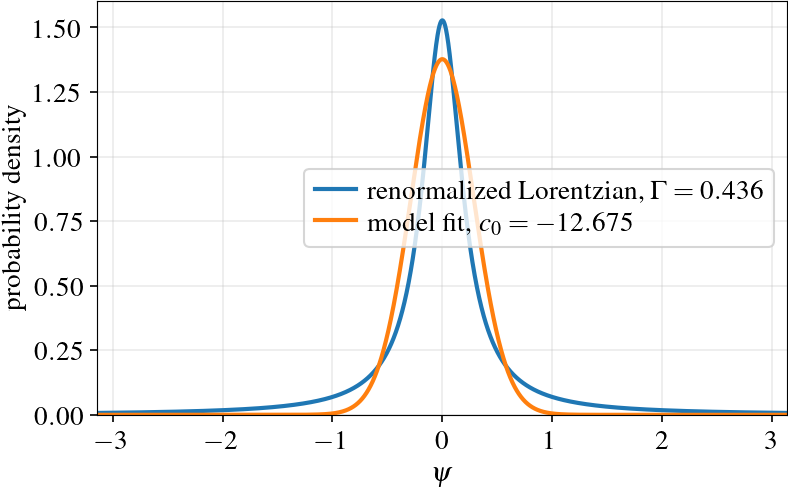

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.special import iv, modstruve

from pathlib import Path
parent_dir = Path.cwd().parent
plt.style.use(parent_dir / "softmatter.mplstyle")


def lorentzian(psi, Gamma=1.2):
    # Raw Lorentzian
    L = (Gamma / (2*np.pi)) / (Gamma**2 / 4 + psi**2)

    # Normalize on [-pi, pi]
    norm = (2 / np.pi) * np.arctan(2*np.pi / Gamma)

    return L / norm


def f2d(psi, c0):
    x = c0 * np.cos(psi)

    return 0.25 * c0 / np.sinh(c0) * (
        -iv(1, x) + modstruve(-1, x)
    )


# Parameters
Gamma = 0.436 # 1.2
psi = np.linspace(-np.pi, np.pi, 4000)


# Fit c0 by least squares
def loss(c0):
    return np.trapezoid(
        (f2d(psi, c0) - lorentzian(psi, Gamma))**2,
        psi
    )


res = minimize_scalar(
    loss,
    bounds=(-50, -1e-8),
    method="bounded"
)

c0_fit = res.x

print(f"c0_fit = {c0_fit:.6f}")
print(f"L2 loss = {res.fun:.6e}")


# Plot
plt.figure(figsize=(5.6, 3.6), dpi=150)

plt.plot(
    psi,
    lorentzian(psi, Gamma),
    label=rf"renormalized Lorentzian, $\Gamma={Gamma}$"
)

plt.plot(
    psi,
    f2d(psi, c0_fit),
    label=rf"model fit, $c_0={c0_fit:.3f}$"
)

plt.xlabel(r"$\psi$")
plt.ylabel(r"probability density")
plt.xlim(-np.pi, np.pi)
plt.ylim(bottom=0)
plt.grid(alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

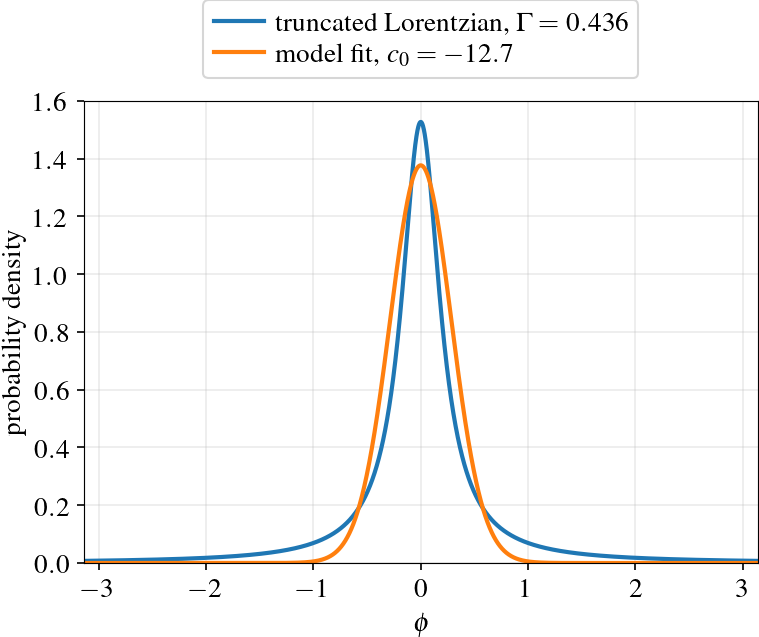

In [27]:
# Plot
fig, ax = plt.subplots(figsize=(5.8, 4.0), dpi=150)

ax.plot(
    psi,
    lorentzian(psi, Gamma),
    label=rf"truncated Lorentzian, $\Gamma={Gamma}$"
)

ax.plot(
    psi,
    f2d(psi, c0_fit),
    label=rf"model fit, $c_0={c0_fit:.1f}$"
)

ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"probability density")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(bottom=0, top=1.6) # ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)

# Legend outside the plot frame, above the axes
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=1,
    frameon=True,
    handlelength=1.8,
    columnspacing=1.2
)

# fig.tight_layout()
# plt.show()


fig.savefig("lorentzian_fit.pdf", bbox_inches="tight")
plt.show()